<a href="https://colab.research.google.com/github/CMorgadoM/ML-Proyect/blob/main/tarea%20ML%20V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Viendo como integrar colab con github

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
enlace_mat = 'https://raw.githubusercontent.com/CMorgadoM/ML-Proyect/refs/heads/main/student-mat.csv'
df_mat = pd.read_csv(enlace_mat, sep=";")
df_mat['Prueba'] = 1

enlace_por = 'https://raw.githubusercontent.com/CMorgadoM/ML-Proyect/refs/heads/main/student-por.csv'
df_por = pd.read_csv(enlace_por, sep=";")
df_por['Prueba'] = 0

# Defino variable de indicador de prueba, valor 1 es matemarica, valor 0 es portugues

df = pd.concat([df_mat, df_por], ignore_index=True)

print(df_mat.shape)
print(df_por.shape)
print(df.shape)

(395, 34)
(649, 34)
(1044, 34)


In [3]:
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'G1', 'G2', 'G3', 'Prueba'],
      dtype='object')

In [4]:
# Quito las pruebas intermedias y me quedo solo con la nota final (G3), que será la variable dependiente

df = df[['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences','Prueba','G3']]


# Descripción del problema a análizar

La base de datos contiene registros de estudiantes de dos escuelas de portugal, con multiples variables de caracterización de los individuos (sexo, tamaño del grupo familiar, nivel educacional de los padres, tiempo destinado a estudio, etc.) y que se usará para generar un modelo del rendimiento del estudiante. Con objetivo de entender de mejor forma el impacto de cada variables en el resultado final del estudiante y de poder generar un predictor de rendimiento para estudiantes futuros.

Se ocupara regresión lineal regularizada (Lasso) para predecir la nota final de la prueba, identificando las variables relevantes del modelo.

Adicionalmente se utilizara un algoritmo de Random Forest para predecir la probación del estudiantes (entendida aprobación como obtención de una nota superior a 9.5)

# Descripción y Codificación de variables

## Variables de entorno y caracterización

Se observa que la mayor parte de estudiantes pertenece a la escuela GP, tienen familias sobre los 3 integrantes; más de la mitad son mujeres y la mayoría vive en zonas urbanas.

Más del 90% de la muestra vive con padres juntos (T) y solo un 10% tiene padres separados (A).

Además declaran que la principal razón para ingresar a su escuela es la oferta de cursos disponibles.

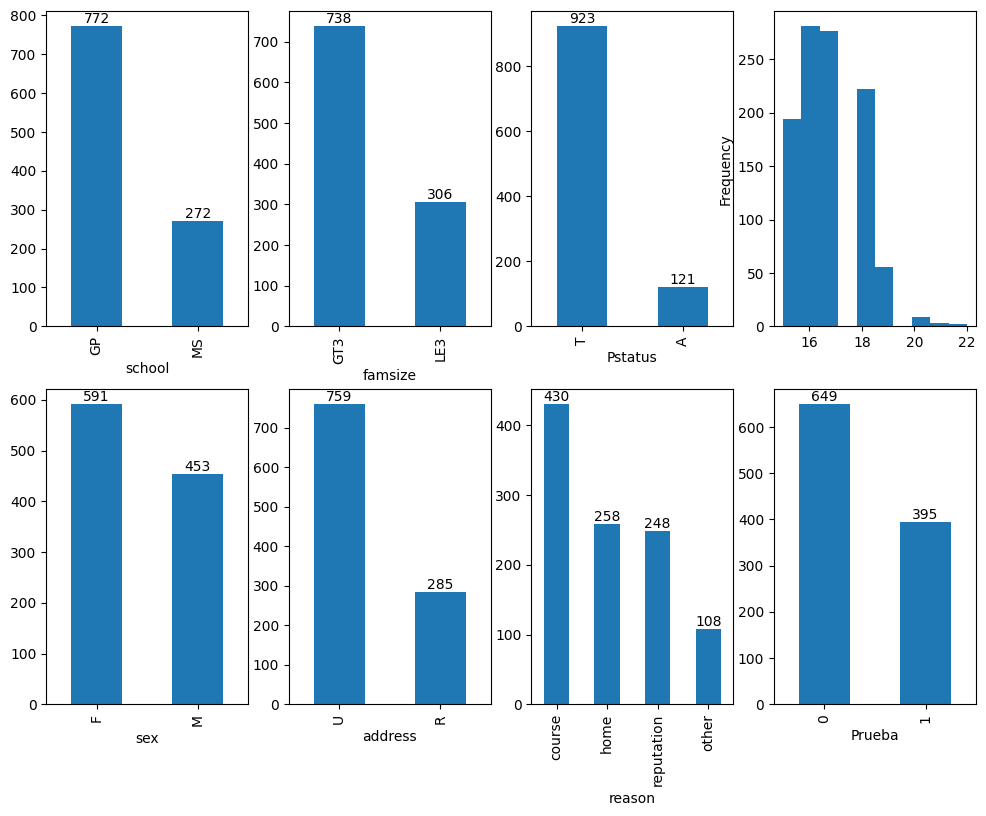

In [66]:
fig,  ax = plt.subplots(2,4, figsize = (12,9))

df['school'].value_counts().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['sex'].value_counts().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['famsize'].value_counts().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['address'].value_counts().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['Pstatus'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['reason'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])

df['age'].plot(kind="hist", ax = ax[0,3])
#ax[0,3].bar_label(ax[0,3].containers[0])

df['Prueba'].value_counts().plot(kind="bar", ax = ax[1,3])
ax[1,3].bar_label(ax[1,3].containers[0])

plt.show()

## Caracterización de los padres

Se observa que hay padres y madres de todos los niveles educacionales, destacandose en las madres los niveles "Segundo ciclo" (2) y "Educación superior" (4) y en padres el nivel "Segundo ciclo" (2). Ambos progenitores declaran trabajar mayormente en "otro" tipo de trabajo, fuera de las categorías presentadas. Vale la pena destacar el mayor numero de madres que trabajan en el hogar versus el escaso numero de padres.

En más de 70% se declara a la madre como la cuidadora del estudiante y un 61% de los estudiantes indica que recibe apoyo de su familia para estudiar.

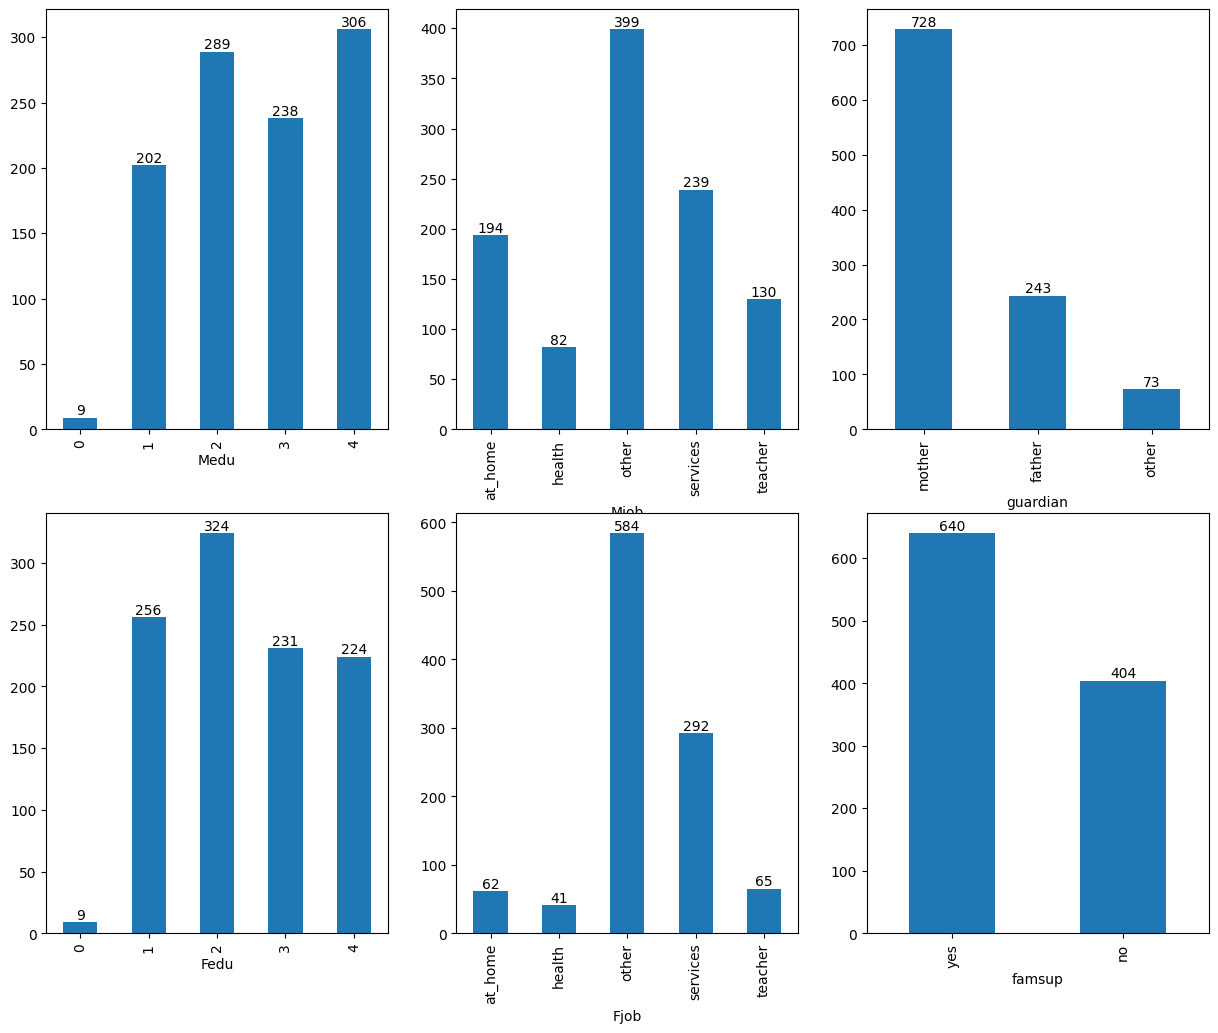

In [35]:
# Caracteristicas de los padres
fig,  ax = plt.subplots(2,3, figsize = (15,12))

df['Medu'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['Fedu'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['Mjob'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['Fjob'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['guardian'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['famsup'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])
plt.show()

## Caracterización del estudiante

Se observa que la mayoría de los estudiantes ingresan a la categoría 1 de tiempo de traslado hasta el colegio (menos de 15 minutos) y que mientras mayor el tiempo de traslado menor es el número de estudiantes.

En cuanto a horas de estudio semanal, la mitad de la muestra declara estudiar entre 2 a 5 horas (categoría 2), seguido de una o dos horas a la semana (categoría 1). Se observa tambien que la mayoría ha tenido pocas faltas a clases, con pocos casos extremos que han faltado más de 20 días en total.

La mayoría de estudiantes no ha tenido ramos reprobados, quiere ir a la educación superior, no recib clases pagadas aparte de su colegio y declara no recibir apoyo de su escuela para llevar a cabo sus estudios.

Aproximadamente la mitad de la muestra declara realizar actividades despues de la escuela.


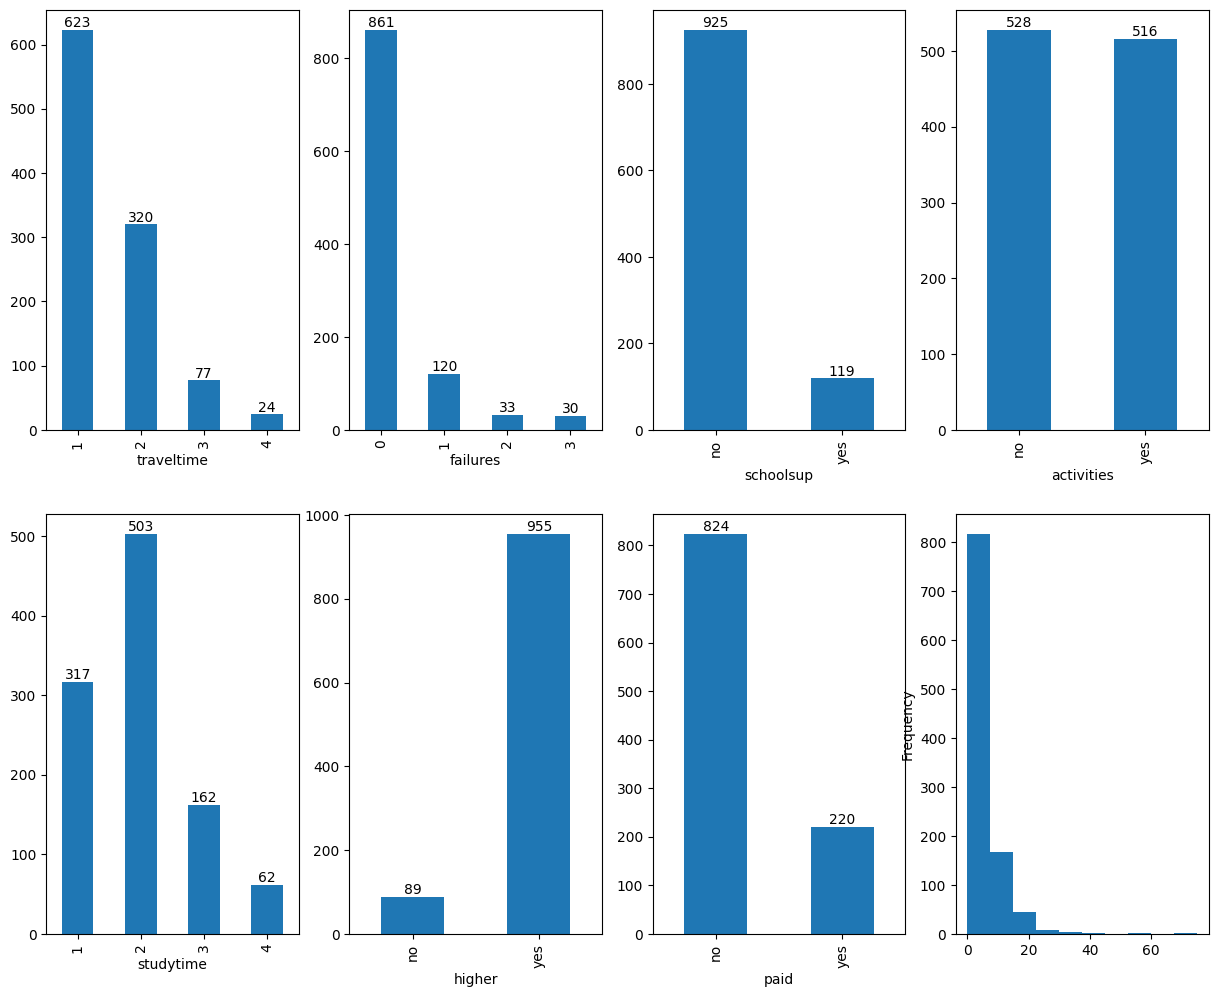

In [40]:
# Caracterización del estudiante
fig,  ax = plt.subplots(2,4, figsize = (15,12))

df['traveltime'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['studytime'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['failures'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['higher'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['schoolsup'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['paid'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])

df['activities'].value_counts().plot(kind="bar", ax = ax[0,3])
ax[0,3].bar_label(ax[0,3].containers[0])

df['absences'].plot(kind="hist", ax = ax[1,3])
#ax[1,3].bar_label(ax[1,3].containers[0])

plt.show()

## Variables de salud y bienestar del estudiante

El tiempo libre del que disfrutan se codifica en la variable freetime, una variable de tipo likert donde la moda es 3 (intermedio) y la distribución se encuentra cargada hacia los valores 4 y 5 (alto y muy alto).

Situación similar resulta de las salidas con amigos (variable goout), centrada al rededor de "intermedio", pero con la categoria "bajo" siendo más preponderante en este caso. Tambien destaca que 673 estudiantes reportan no tener una relación sentimental al momento de la encuesta.

Se seañala que un 79% de los estudiantes cuentan con internet en sus casas.

La salud general de los estudiantes (variable health) es reportada como muy buena para un gran número de estudiantes. Aunque, hay 260 alumnos que indican tener mala o muy mala salud.

Variables Dalc y Walc reflejan el consumo de alcohol en día laboral y findesemana respectivamente. En ambos casos la moda indica la categoría "muy bajo", pero el cosnumo en findesemana se observa mayor que el consumo de alcohol en día laboral.

Finalmente, 835 estudiantes reportan haber visitado la enfermería de su establecimiento alguna vez.


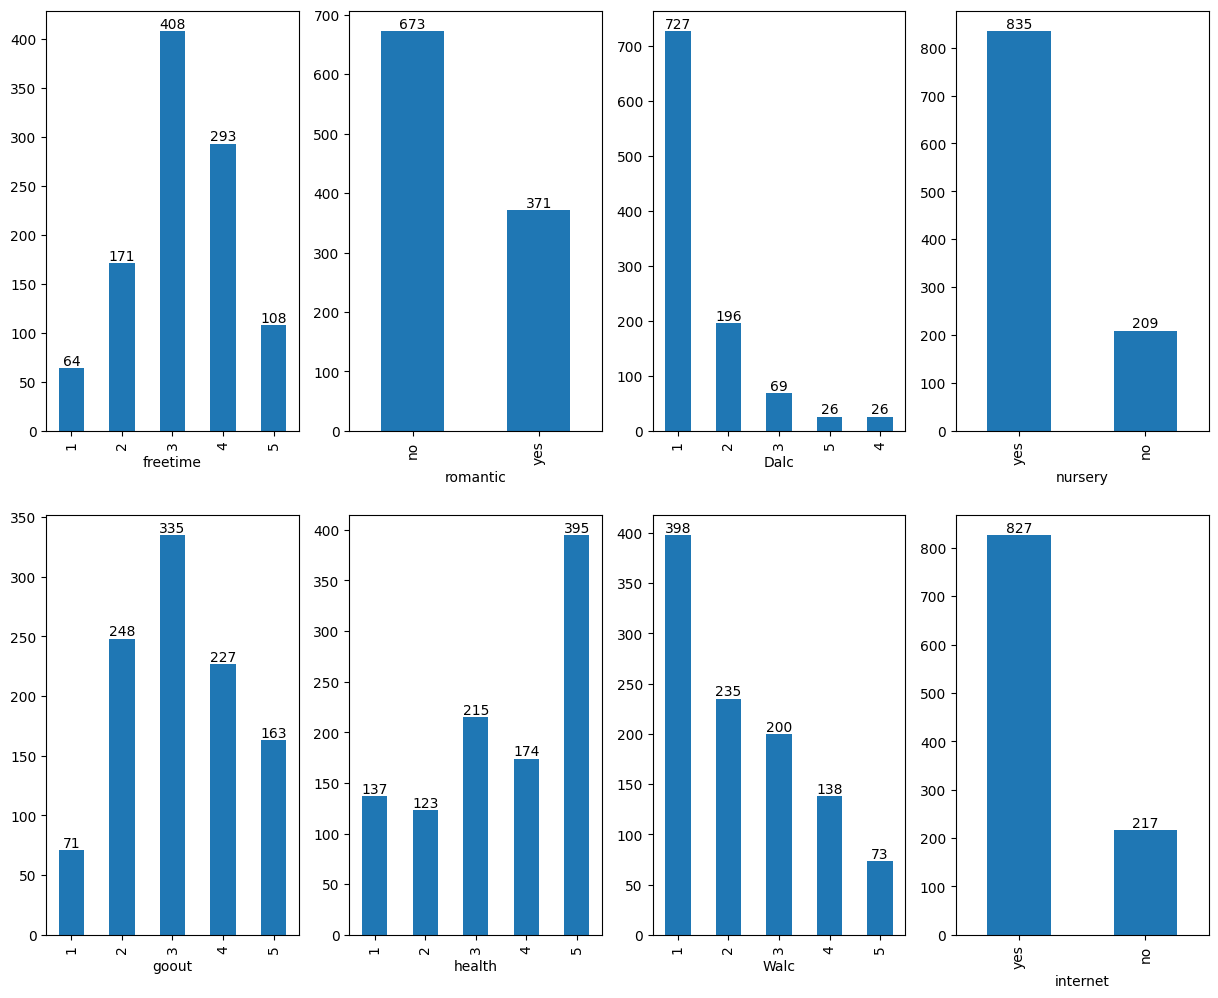

In [41]:
# Caracterización del estudiante
fig,  ax = plt.subplots(2,4, figsize = (15,12))

df['freetime'].value_counts().sort_index().plot(kind="bar", ax = ax[0,0])
ax[0,0].bar_label(ax[0,0].containers[0])

df['goout'].value_counts().sort_index().plot(kind="bar", ax = ax[1,0])
ax[1,0].bar_label(ax[1,0].containers[0])

df['romantic'].value_counts().sort_index().plot(kind="bar", ax = ax[0,1])
ax[0,1].bar_label(ax[0,1].containers[0])

df['health'].value_counts().sort_index().plot(kind="bar", ax = ax[1,1])
ax[1,1].bar_label(ax[1,1].containers[0])

df['Dalc'].value_counts().plot(kind="bar", ax = ax[0,2])
ax[0,2].bar_label(ax[0,2].containers[0])

df['Walc'].value_counts().plot(kind="bar", ax = ax[1,2])
ax[1,2].bar_label(ax[1,2].containers[0])

df['nursery'].value_counts().plot(kind="bar", ax = ax[0,3])
ax[0,3].bar_label(ax[0,3].containers[0])

df['internet'].value_counts().plot(kind="bar", ax = ax[1,3])
ax[1,3].bar_label(ax[1,3].containers[0])


plt.show()

## Notas del estudiante

La variable de respuesta en este estudio será la nota de finalización de curso del estudiante. Esta presenta un promedio de 11.34 una mediana en 11 y una desviación estandar de 3.86 puntos.

Del comportamiento de esta vaiable vale destacar:
* Hay un número de observaciones con nota 0. Presumiblemente gente que deserto del ramo.
* Hay un salto entre la nota 9 y las notas 10 o mayores, que corresponde a la nota mínima de aprobación del curso. Esto podría indicar profesores "ajustando" la nota de estudiantes para lograr aprobar

Ambas condiciones afectaran el desempeño final del modelo.

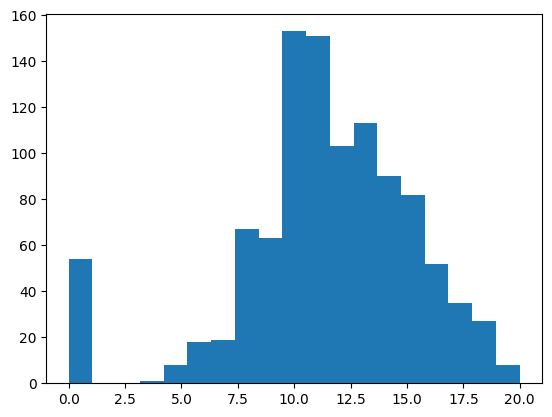

In [51]:
plt.hist(df['G3'], bins=19);

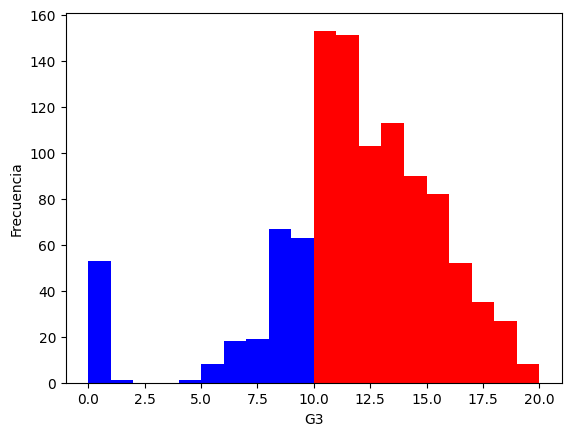

In [47]:
# Crear el histograma y capturar los patches
n, bins, patches = plt.hist(df['G3'], bins=20)

# Colorear de rojo las barras donde el valor es > 9.5
for i, patch in enumerate(patches):
    if bins[i] > 9.5:
        patch.set_facecolor('red')
    else:
        patch.set_facecolor('blue')  # Color para valores <= 9.5

plt.xlabel('G3')
plt.ylabel('Frecuencia')
plt.show()


In [45]:

#
df['G3'].describe()


,G3
count,1044.000000
mean,11.341954
std,3.864796
min,0.000000
25%,10.000000
50%,11.000000
75%,14.000000
max,20.000000


In [42]:
df['school'].value_counts()
df['sex'].value_counts()
df['Dalc'].value_counts()
df['Walc'].value_counts()
#'traveltime',
#    'studytime'
df['traveltime'].value_counts()
df.columns
#df['health'].value_counts()

Index(['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu',
       'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc',
       'Walc', 'health', 'absences', 'Prueba', 'G3'],
      dtype='object')

In [ ]:
cat_variables = [
    'sex', # Indicador de sexo, valor Femenino=0, masculino=1
    'school', # MS:1 ; GP:0
    'famsize', #  menos de 3(LE3):1 ;  mayor a 3(GT3):0
    'address', # Urbana(U):1 ; Rural(R):0
    'Pstatus', # pades viven juntos(T):1 ; padres viven separados(A):0
    'Medu', # Nivel educacional de la madre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Fedu', # Nivel educacional de la padre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Mjob', # Tipo de ocupación de la madre, se deja fuera at_home
    'Fjob', # Tipo de ocupación del padre, se deja fuera at_home
    'reason', # rason para entrar a esta escuela; home= vive cerca de la escuela; reputation=reputacion de la escuela; other=otras razones; course=preferencia por cursos dictados (queda fuera)
    'guardian', # quien cuida al menor, queda fuera padre
    'traveltime',
    'studytime',
    'schoolsup', # recive apoyo escolar
    'famsup', # recibe apoyo familiar
    'paid', # Recibe clases extra en la materia
    'activities', # participa en actividades extracurriculares
    'nursery', # la escuela tiene enfermería
    'higher', # el estudiante aspira a educación superior
    'internet', # internet en casa
    'romantic', # estudiante con relación romantica
    'famrel', # escala likert de calidad de relaciones familiares
    'freetime', # escala likert de cantidad de tiempo libre
    'goout', # Escala likert de salida con amigos
    'Dalc', # Escala likert de Consumo de alcohol en días laborales
    'Walc', # Escala likert de Consumo de alcohol en fin de semana
    'health' # Escala likert de salud general del estudiante
    ]

Dado el alto número de variables categoricas, usando el metodo de V de Cramér se busca identificar correlación entre las variables explicativas. Como resultado no se observa alta correlación entre ninguna de lasc variables categoricas estudiadas.

Se observa que las correlaciones más altas se dan entre Medu (nivel educacional de la madre) con Fedu (Nivel educacional del padre) y Mjob (trabajo de la madre) y entre las variables de consumo de alcohol en día laboral o findesemana (Dalc y Walc).

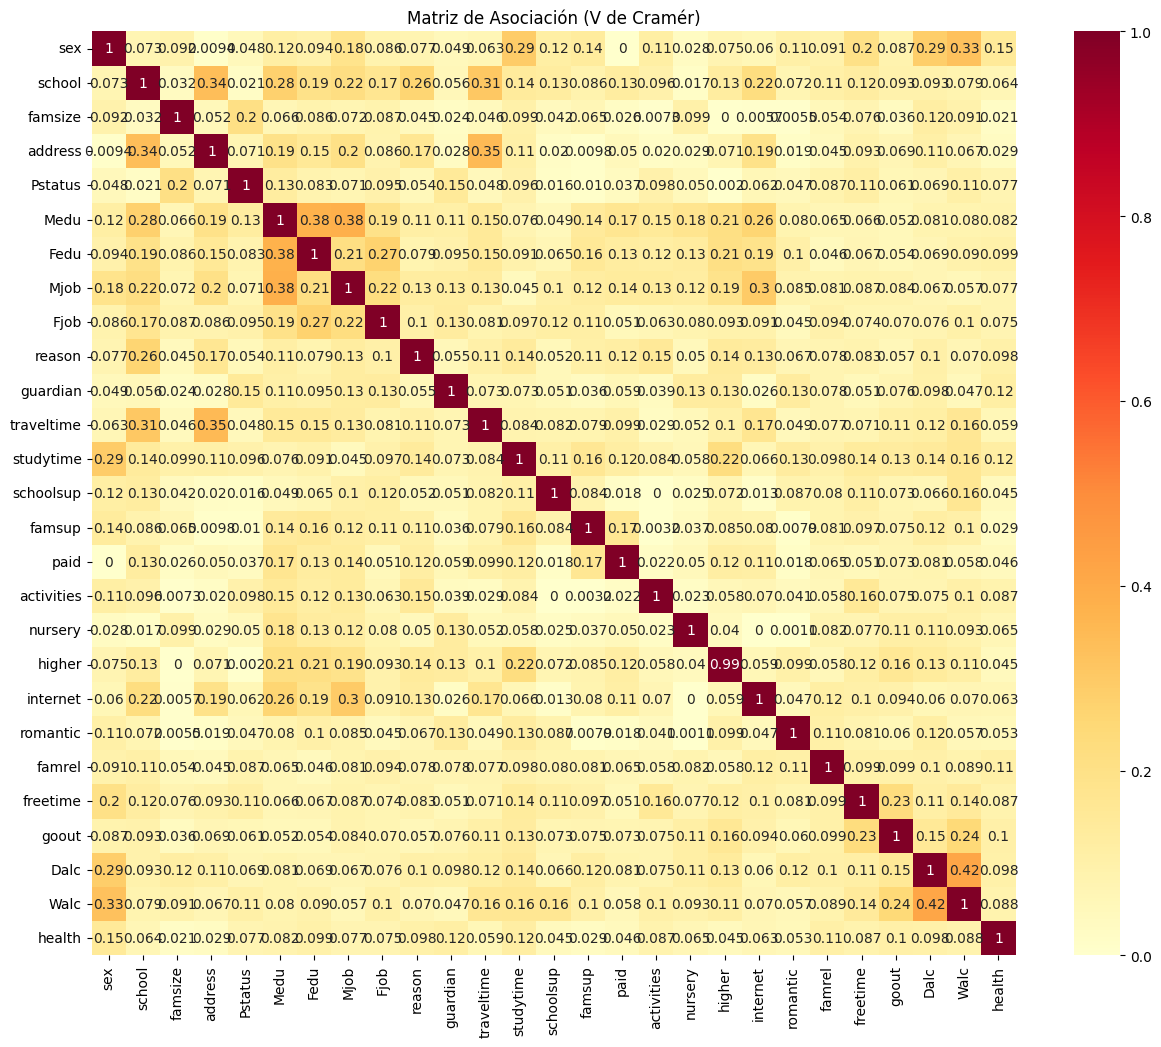

In [64]:
# en honor al tiempo este codigo lo genero una IA, cambie solo el input y las dimensiones del grafico de salida.
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

# Crear matriz de correlaciones
n_vars = len(cat_variables)
cramers_matrix = pd.DataFrame(np.zeros((n_vars, n_vars)),
                               columns=cat_variables,
                               index=cat_variables)

# Calcular V de Cramér para cada par
for i, var1 in enumerate(cat_variables):
    for j, var2 in enumerate(cat_variables):
        cramers_matrix.iloc[i, j] = cramers_v(df[var1], df[var2])

# Visualizar como heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(cramers_matrix, annot=True, cmap='YlOrRd',
            vmin=0, vmax=1, square=True)
plt.title("Matriz de Asociación (V de Cramér)")
plt.show()

## Codificación de variables

Dado que gran parte de las variables están codificadas como variables categorica se decidio trabajar mediante metodología one-hot encoding, de esta forma se genera una variable con valores 1 o 0 que indiquen el cumplimiento o no de cierta condición de la categoría. En cada caso (para evitar multicolinearidad) se deja una de las categorías afuera del modelo, la que es representada por el intercepto en la regresión.

Variables de tipo likert se trataron en este estudio mediante la misma metodología, buscando no asumir linealidad en la interpretación de las notas registradas por la escala likert. Una desventaja de esto es la perdida de poder interpretativo, pues el coeficiente de cada dummy entregara menos información que la variables agrupada, perdiendose tambien la propiedad ordinal de las escalas likert. En contraste, se busca aumentar el poder predictivo del modelo, generando un mejor fit con los datos (lo que será particularmente util en la aplicación de random forest, bajo la consideración de riesgo de overfitting).


In [52]:
# MYoEdu = [0 if i == 0 else 4 if i == 1 else 9 if i == 2 else 12 if i == 3 else 16 for i in df.Medu] # Convierto la variable a años de educación
# FYoEdu = [0 if i == 0 else 4 if i == 1 else 9 if i == 2 else 12 if i == 3 else 16 for i in df.Fedu] # Convierto la variable a años de educación


# variables tipo likert


# One hot encoding de las variables categoricas
# Variables tipo escala de likert se trabajan como categoricas, para no asumir distnacia lineal entre las categorías
cat_variables = [
    'sex', # Indicador de sexo, valor Femenino=0, masculino=1
    'school', # MS:1 ; GP:0
    'famsize', #  menos de 3(LE3):1 ;  mayor a 3(GT3):0
    'address', # Urbana(U):1 ; Rural(R):0
    'Pstatus', # pades viven juntos(T):1 ; padres viven separados(A):0
    'Medu', # Nivel educacional de la madre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Fedu', # Nivel educacional de la padre; 0-ninguno, 1-primer ciclo, 2-segundo ciclo, 3-secundaria completa, 4-educación superior
    'Mjob', # Tipo de ocupación de la madre, se deja fuera at_home
    'Fjob', # Tipo de ocupación del padre, se deja fuera at_home
    'reason', # rason para entrar a esta escuela; home= vive cerca de la escuela; reputation=reputacion de la escuela; other=otras razones; course=preferencia por cursos dictados (queda fuera)
    'guardian', # quien cuida al menor, queda fuera padre
    'traveltime',
    'studytime',
    'schoolsup', # recive apoyo escolar
    'famsup', # recibe apoyo familiar
    'paid', # Recibe clases extra en la materia
    'activities', # participa en actividades extracurriculares
    'nursery', # la escuela tiene enfermería
    'higher', # el estudiante aspira a educación superior
    'internet', # internet en casa
    'romantic', # estudiante con relación romantica
    'famrel', # escala likert de calidad de relaciones familiares
    'freetime', # escala likert de cantidad de tiempo libre
    'goout', # Escala likert de salida con amigos
    'Dalc', # Escala likert de Consumo de alcohol en días laborales
    'Walc', # Escala likert de Consumo de alcohol en fin de semana
    'health' # Escala likert de salud general del estudiante
    ]

dummies_df = pd.get_dummies(df, columns=cat_variables, drop_first=True, dtype=int)
dummies_df

,age,failures,absences,Prueba,G3,sex_M,school_MS,famsize_LE3,address_U,Pstatus_T,...,Dalc_4,Dalc_5,Walc_2,Walc_3,Walc_4,Walc_5,health_2,health_3,health_4,health_5
0,18,0,6,1,6,0,0,0,1,0,...,0,0,0,0,0,0,0,1,0,0
1,17,0,4,1,6,0,0,0,1,1,...,0,0,0,0,0,0,0,1,0,0
2,15,3,10,1,10,0,0,1,1,1,...,0,0,0,1,0,0,0,1,0,0
3,15,0,2,1,15,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
4,16,0,4,1,10,0,0,0,1,1,...,0,0,1,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039,19,1,4,0,10,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,1
1040,18,0,4,0,16,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1041,18,0,6,0,9,0,1,0,1,1,...,0,0,0,0,0,0,0,0,0,1
1042,17,0,6,0,10,1,1,1,1,1,...,0,0,0,0,1,0,1,0,0,0


In [61]:
dummies_df.columns

Index(['age', 'failures', 'absences', 'Prueba', 'G3', 'sex_M', 'school_MS',
       'famsize_LE3', 'address_U', 'Pstatus_T', 'Medu_1', 'Medu_2', 'Medu_3',
       'Medu_4', 'Fedu_1', 'Fedu_2', 'Fedu_3', 'Fedu_4', 'Mjob_health',
       'Mjob_other', 'Mjob_services', 'Mjob_teacher', 'Fjob_health',
       'Fjob_other', 'Fjob_services', 'Fjob_teacher', 'reason_home',
       'reason_other', 'reason_reputation', 'guardian_mother',
       'guardian_other', 'traveltime_2', 'traveltime_3', 'traveltime_4',
       'studytime_2', 'studytime_3', 'studytime_4', 'schoolsup_yes',
       'famsup_yes', 'paid_yes', 'activities_yes', 'nursery_yes', 'higher_yes',
       'internet_yes', 'romantic_yes', 'famrel_2', 'famrel_3', 'famrel_4',
       'famrel_5', 'freetime_2', 'freetime_3', 'freetime_4', 'freetime_5',
       'goout_2', 'goout_3', 'goout_4', 'goout_5', 'Dalc_2', 'Dalc_3',
       'Dalc_4', 'Dalc_5', 'Walc_2', 'Walc_3', 'Walc_4', 'Walc_5', 'health_2',
       'health_3', 'health_4', 'health_5'],
      d

In [56]:
from scipy.stats import chi2_contingency
import seaborn as sns

# Ejecución Lasso

El modelo Lasso se plantea como una regresión lineal ajustada con regularización L1, esto implica la siguiente función de costos:

$$RSS_{lasso} = \sum_{i=1}^{n} (y_i - f(x_i))^2 + \lambda \sum_{j=1}^{p} |\beta_j|$$


En la ecuación se representa el componenete de minimos cuadrados de una función de costo tipica de un modelo linea, sumando además un componente adicional formado por la sumatoria del valor absoluto de los coeficientes del modelo por una tasa de ajuste lambda (hiperparametro alpha en sklearn)

## Selección del modelo

Para evaluar el modelo se separa el conjunto completo de datos en sets de entrenamiento (80% de la muestra) y de testeo (20% de la muestra).

Los modelos a testear variarán respecto al valor de $λ$ y la metrica de interes, al ser un problema de regresión será el $R^2$  del modelo, eligiendose como mejor modelo aquel que, dado cierto valor del parametro $λ$, el que entregue un mayor $R^2$.

In [53]:
# Cargo paquetes para lasso

from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score


In [123]:
X = dummies_df.drop('G3', axis=1)
y = dummies_df[['G3']]
print(X.head()) # Chequeamos que las variables se guardaran correctamente
print(y.head())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)
# Revisamos dimensiones de los sets de entrenamiento y testeo
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

   age  failures  absences  Prueba  sex_M  school_MS  famsize_LE3  address_U  \
0   18         0         6       1      0          0            0          1   
1   17         0         4       1      0          0            0          1   
2   15         3        10       1      0          0            1          1   
3   15         0         2       1      0          0            0          1   
4   16         0         4       1      0          0            0          1   

   Pstatus_T  Medu_1  ...  Dalc_4  Dalc_5  Walc_2  Walc_3  Walc_4  Walc_5  \
0          0       0  ...       0       0       0       0       0       0   
1          1       1  ...       0       0       0       0       0       0   
2          1       1  ...       0       0       0       1       0       0   
3          1       0  ...       0       0       0       0       0       0   
4          1       0  ...       0       0       1       0       0       0   

   health_2  health_3  health_4  health_5  
0         0 

Para encontrar el mejor valor para $λ$ Se itera con 5000 valores entre 0 y 20 (se definio este rango pues es la escala de valores que puede tomar la variable de respuesta), para cada iteración guardandose el valor del hyperparametro y del $R^2$ resultante.

Se identifica aquella iteración que entrega el mejor resultado y se selecciona el valor respectivo de $\lambda$.

En esta aplicación del modelo, el mejor valor encontrado fue de $\lambda$ = 0.04, resultando en un $R^2$ de 0.3.

In [67]:

param_vals = []
r2_vals = []

for alpha_val in np.linspace(0, 20, num=5000):
  l1_iter_model = Lasso(alpha = alpha_val)
  l1_iter_model.fit(X_train, y_train)
  y_hat = l1_iter_model.predict(X_test)
  param_vals.append(alpha_val)
  r2_vals.append(r2_score(y_test, y_hat))

max_r2 = np.argmax(r2_vals)
print(f'El mayor r2 encontrado es {r2_vals[max_r2]}, con un parametro alpha = {param_vals[max_r2]}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.369e+03, tolerance: 1.324e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent

El mayor r2 encontrado es 0.30006824738700255, con un parametro alpha = 0.040008001600320066


## Resultados del modelo

Ocupando el resultado del análisis anterior, se modela una regresión linear Lasso con valor $λ$ = 0.04 y un $R^2$ de 0.3.

Mediante estas especificaciones el algoritmo forzo 35 variables a tener un valor de parametro 0, mientras que 33 tuvieron valor distinto de cero.

### Variables relevantes

Las 5 variables más relevantes, con coeficiente positivo fueron:
* higher_yes, con valor 1.232911
* Medu_4, con valor 	0.869574
* studytime_3, con valor 	0.777202
* goout_2, con valor 	0.720136
* Mjob_services, con valor 	0.459040

Las 5 variables más relevantes, con coeficiente negativo fueron:
* Prueba, con valor 	-1.589513
* failures, con valor 	-1.544866
* schoolsup_yes, con valor 	-0.750259
* school_MS, con valor 	-0.632397
* romantic_yes, con valor 	-0.620416

Esto implica un alto peso relativo de la intención de buscar estudios superiores en la nota final del curso. Tambien impacta positivamente que la madre tenga estudios universitarios (no así el padre), tener tiempo libre moderado, salir poco con amigos y que la madre trabaje en el sector de servicios.

Esta negativamente correlacionado con la nota, en tanto, haber reprobado cursos en el pasado, estar en una relación romantica (se puede interpretar que por el consumo de tiempo que requiere).

Castiga tambien la nota estar matrículado en la escuela "Mousinho da Silveira" (MS) y hay peores notas en la prueba de matematicas (1) que en la de portugues.

Tambien esta negativamente correlacionado el recibir apoyo de la escuela, lo que tiene sentido considerando que es posible que los estudiantes menos aventajados sean aquellos que reciban apoyo.

### Variables no consideradas

Entre las variables no consideradas por el modelo destacan el nivel educacional del padre (ninguna de sus categorías), el sexo o la edad.

El tiempo de desplazamiento hasta el colegio solo fue considerado relevantes aquellos que vivian muy cerca o muy lejos (eliminando los intermedios).

No fueron considerados relevante el tener una buena relación con la familia (famrel en su categoria 2, 3 y 5) ni tener el apoyo de la familia para estudiar.

Tener mucho tiempo libre no perjudico ni ayudo al rsultado final del curso (no considerandose freetime en sus categorías 4 y 5)


In [68]:
# implementamos lasso
l1_model = Lasso(alpha = 0.04)
l1_model.fit(X_train, y_train)

y_hat = l1_model.predict(X_test)
r2_score(y_test, y_hat)

0.3000685286437247

In [72]:
coef_l1 = pd.Series(l1_model.coef_,
          index=X_train.columns)

In [78]:
print(f'''
El modelo finaliza con {len(coef_l1[coef_l1 != 0])} variables con coeficiente distinto de cero.
Producto de la regularización se eliminan del modelo {len(coef_l1[coef_l1 == 0])} variables.
'''
)


El modelo finaliza con 33 variables con coeficiente distinto de cero.
Producto de la regularización se eliminan del modelo 35 variables.



In [77]:
coef_l1[coef_l1 != 0].sort_values(ascending=False)[0:5]

,0
higher_yes,1.232911
Medu_4,0.869574
studytime_3,0.777202
goout_2,0.720136
Mjob_services,0.459040
goout_3,0.421035
address_U,0.391519
freetime_2,0.350766
reason_reputation,0.341732
internet_yes,0.300882


In [81]:
coef_l1[coef_l1 != 0].sort_values(ascending=True)[0:5]

,0
Prueba,-1.589513
failures,-1.544866
schoolsup_yes,-0.750259
school_MS,-0.632397
romantic_yes,-0.620416


In [80]:
coef_l1[coef_l1 == 0].sort_index()

,0
Dalc_3,0.0
Dalc_5,-0.0
Fedu_1,-0.0
Fedu_2,0.0
Fedu_3,-0.0
Fedu_4,0.0
Fjob_health,0.0
Fjob_other,-0.0
Medu_3,0.0
Mjob_other,-0.0


# Ejecución Random Forest

## Metrica a evaluar

Para evaluar el modelo se exploran diferentes metricas, pero dado que estoy prediciendo los alumnos que van a aprobar o reprobar un curso, me interesa minimizar el ratio de falsos positivos del algoritmo (Clasificar a alguien como aprobado, siendo que es reprobado) pues estimar que alguien reprobara puede dar la alerta para aplicar medidas correctivas a tiempo, en cambio, asumir que alguien con alta probabilidad de reprobar obtendra nota sobre 9.5 puede hacer que tanto profesor como estudiante se relajen y no tomen las medidas adecuadas.

En orden de minimizar esto, se optimiza el modelo para aumentar la precisión,  esto es:



$$Precisión = Verdaderos Positivos / (Verdaderos Positivos + Falsos Positivos)$$



Los parametros se seleccionaran mediante un algoritmo de GridSearch Cross-Validation, optimizando para precisión.

Los hyperparametros a modular son el numero de arboles (n_estimators) y el tamaño de los arboles generados (max_depth). Se seleccionan estos en busca de obtener un buen modelo cuidando la correcta generalización a datos nuevos.

In [141]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV

In [124]:
y_train_class = [1 if i >= 10 else 0 for i in y_train.G3]
y_test_class = [1 if i >= 10 else 0 for i in y_test.G3]

In [86]:
np.mean(y_train_class)

np.float64(0.770059880239521)

In [87]:
np.mean(y_test_class) # aprox 80% de aprobados en ambos sets

np.float64(0.8181818181818182)

In [143]:
param_grid = {
    'n_estimators':[100, 200, 300, 400, 500], # Para modular el numero de modelos, cuidado con el overfitting
    'max_depth':[None, 5, 10, 15, 20, 25, 30] # para modular la complejidad del model
}

grid_search = GridSearchCV(RandomForestClassifier(), param_grid=param_grid, cv=5, scoring='precision')
grid_search.fit(X_train, y_train_class)

print("Best Parameters:", grid_search.best_params_)
print("Best Estimator:", grid_search.best_estimator_)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
Best Estimator: RandomForestClassifier()


In [146]:
# rf_clf = RandomForestClassifier(n_estimators=200, max_depth=20) # optimizado para F1
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=None, random_state=1234) # optimizado para precision
rf_clf.fit(X_train, y_train_class)


RandomForestClassifier(random_state=1234)

In [147]:
print(f'''
Acc = {accuracy_score(y_test_class, rf_clf.predict(X_test))}
recall = {recall_score(y_test_class, rf_clf.predict(X_test))}
precision = {precision_score(y_test_class, rf_clf.predict(X_test))}
f1 = {f1_score(y_test_class, rf_clf.predict(X_test))}
roc_auc_score = {roc_auc_score(y_test_class, rf_clf.predict(X_test))}
''')


Acc = 0.8708133971291866
recall = 0.9824561403508771
precision = 0.875
f1 = 0.9256198347107438 
roc_auc_score = 0.6754385964912281      

